_Restarting Pixi Respighi..._

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xugrid as xu
from shapely.geometry import Point
import gc

import respighi as rsp

In [ ]:
# Set window for area of interest

XMIN = 185_000.0
XMAX = 205_000.0
YMIN = 350_000.0
YMAX = 370_000.0
# XMIN = 170_000.0
# XMAX = XMIN + 15_000.0
# YMIN = 360_000.0
# YMAX = YMIN + 15_000.0

#Define parameters
N_PIEZOMETERS = 200
TRANSMISSIVITY = 2200.00
RECHARGE = 0.0001
REG_WEIGHT = 1000
SEED = 12345

In [ ]:
def slice_dataset(ds):
    return ds.sel(x=slice(XMIN, XMAX), y=slice(YMAX, YMIN))

SCENARIO = ""   # "" for original, "-cond0.5", "-cond2", "-cond3"

BASE = "../../case/ibrahym/ibrahym-"

head = xr.open_dataset(f"{BASE}head-l1-100m.nc")["head"]
modelhead = slice_dataset(head.isel(time=-1))
drain_ds        = slice_dataset(xr.open_dataset(f"{BASE}drains-100m{SCENARIO}.nc"))
river_ds        = slice_dataset(xr.open_dataset(f"{BASE}rivers-100m{SCENARIO}.nc"))
large_river_ds  = slice_dataset(xr.open_dataset(f"{BASE}largerivers-100m{SCENARIO}.nc"))
tiledrain_ds    = slice_dataset(xr.open_dataset(f"{BASE}tiledrainage-100m{SCENARIO}.nc"))
overlandflow_ds = slice_dataset(xr.open_dataset(f"{BASE}overlandflow-100m.nc"))  # always original
subsoil         = slice_dataset(xr.open_dataset(f"{BASE}subsoil-100m.nc"))       # always original
hfb_gdf         = gpd.read_file(f"{BASE.replace('ibrahym-', '')}hfb-12.gpkg")

# Select the winter data
river_ds = river_ds.isel(time=0)

# Create a transmissivity
transmissivity = xr.full_like(subsoil["kh"].isel(layer=0, drop=True), TRANSMISSIVITY)

In [ ]:
# Initialize the relevant boundary condition classes, initialize the
# groundwater model, formulate, then solve.

river = rsp.River.from_dataset(river_ds)
large_river = rsp.River.from_dataset(large_river_ds)
drain = rsp.Drainage.from_dataset(drain_ds)
tiledrain = rsp.Drainage.from_dataset(tiledrain_ds)
overlandflow = rsp.Drainage.from_dataset(overlandflow_ds, constant_conductance=500.0)
recharge = rsp.Recharge(
    rate=xr.full_like(transmissivity, RECHARGE).to_numpy(),
)

hfb = rsp.HorizontalFlowBarrier.from_geodataframe(
    layer=0,
    barriers=hfb_gdf,
    template=transmissivity,
    max_snap_distance=10.0,
) #can be skipped

17.14585996629499
12.830262434492436
2.526016825880724
2.2175777664860057
1.5829168230644157
1.0095105186691669
0.033053666535383996
0.00013389663125096263
7.640827138999384e-06
3.719506764809921e-07


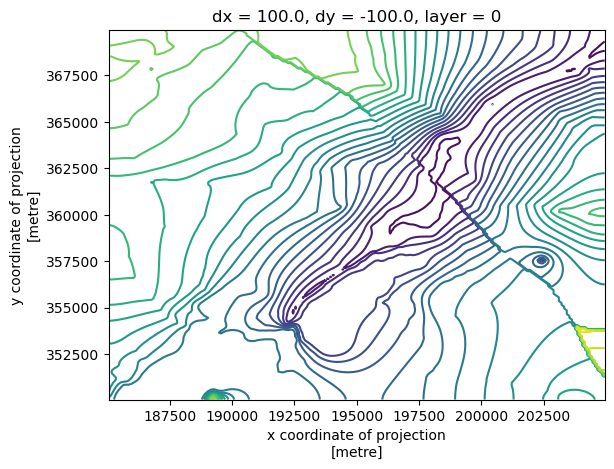

In [ ]:
gwf = rsp.GroundwaterModel(
    area=100.0 * 100.0,
    initial=modelhead,
    recharge=recharge,
    head_boundaries=[river, large_river, drain, tiledrain, overlandflow],
    transmissivity=transmissivity,
    horizontal_flow_barriers=[hfb],
    xclose=1e-6,
    maxiter=50,
)
gwf.formulate()
gwf.nonlinear_solve()
gwf.head.isel(layer=0).plot.contour(levels=30)

In [ ]:
# Make synthetic piezometers


def make_piezometers(n_piezometers, xmin, xmax, ymin, ymax):
    rng = np.random.default_rng(seed=SEED)
    x = xmin + (xmax - xmin) * rng.random(n_piezometers)
    y = ymin + (ymax - ymin) * rng.random(n_piezometers)
    return x, y

#Loading fixed piezometer locations (Cannot be used in conjunction with make_piezometers function, 
# as it will overwrite the generated piezometer locations with the ones from the file)
# piezometers_gdf = gpd.read_file(f"piezometers_seed{SEED}.gpkg")
# x = piezometers_gdf.geometry.x.to_numpy()
# y = piezometers_gdf.geometry.y.to_numpy()


x, y = make_piezometers(
    n_piezometers=200,
    xmin=XMIN,
    xmax=XMAX,
    ymin=YMIN,
    ymax=YMAX,
)

#Store fixed piezometer locations in a GeoPackage file for future reference
geometry = [Point(xi, yi) for xi, yi in zip(x, y)]
piezometers_gdf = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:28992")
piezometers_gdf.to_file(f"piezometers_seed{SEED}.gpkg", driver="GPKG")

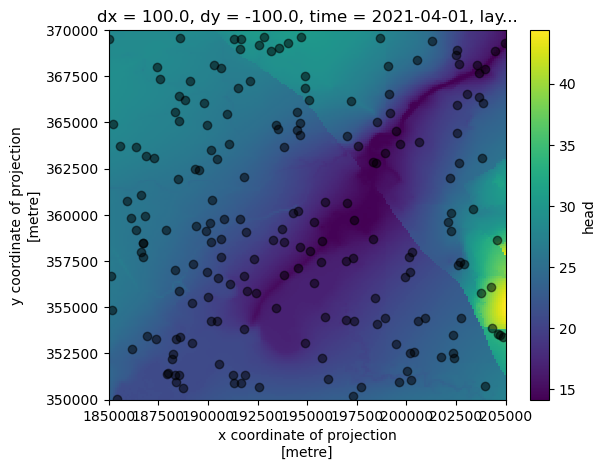

In [ ]:
# Check where they are located
fig, ax = plt.subplots()
modelhead.plot(ax=ax)
ax.scatter(x, y, color="k", alpha=0.5)

In [ ]:
# Make a respighi Target

grid = xu.Ugrid2d.from_structured(modelhead)
headvalues = modelhead.sel(
    x=xr.DataArray(x), y=xr.DataArray(y), method="nearest"
).to_numpy()
target = rsp.CellSampling(x, y, headvalues, grid)

In [ ]:
# Inverse Problem
# ---------------
#
# With the groundwater model and the target, we can pose an inverse problem to solve.

inverse = rsp.InverseProblem(
    groundwatermodel=gwf,
    target=target,
    regularization_weight=REG_WEIGHT,
    maxiter=100,
    relax=0.0,
)

In [ ]:
inverse.formulate()

In [ ]:
# Solve.

inverse.nonlinear_solve()

133.54730275547465
112.79332443013739
33.20419802857896
4.993653298392637
2.1894029388934158
0.19626104857185922
0.024018981940795214
0.023188329841644872
0.021689187539863042
0.021680096257195913
0.021667591870755842
0.02166554062903714
0.021662792574097978
0.021662335174696068
0.02166173569384
0.021661634007269726
0.021661498253493505
0.021661474868228225
0.021661442689069332
0.021661438271852518
0.021661434262604473
0.0216614306346834
0.021661421184738572
0.021661422934180052
0.021661435911816795
0.02166143593235148
0.02166143519849939
0.021661435300675436
0.0216614361773928
0.021661434592484596
0.021661423527728374
0.0216614235976067
0.021661421996533647
0.021661421913787393
0.021661421036871076
0.021661421403795345
0.021661421950383897
0.021661420860681346
0.021661421214083987
0.021661422455835577
0.021661422425513166
0.02166142187651232
0.02166142103103752
0.021661422330112146
0.021661435086230085
0.021661433232576854
0.021661420314774915
0.021661422826028343
0.02166143696752343


C:\Users\sebas\Documents\1Thesis\respighi\respighi\inverse.py:306: UserWarning: Nonlinear solver did not converge after 100 iterations. Final update: 2.17e-02
  warnings.warn(


(False, 100)

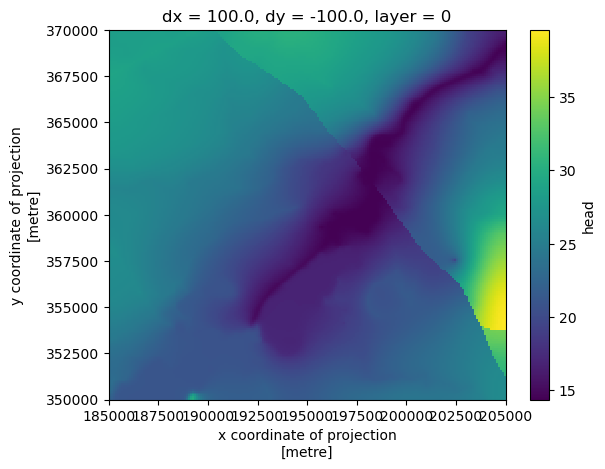

In [ ]:
inversehead = inverse.head.isel(layer=0)
inversehead.plot.imshow()

In [ ]:
error = inversehead - modelhead
print(abs(error).mean())

<xarray.DataArray 'head' ()> Size: 8B
array(0.27709811)
Coordinates:
    dx       float64 8B 100.0
    dy       float64 8B -100.0
    time     datetime64[ns] 8B 2021-04-01


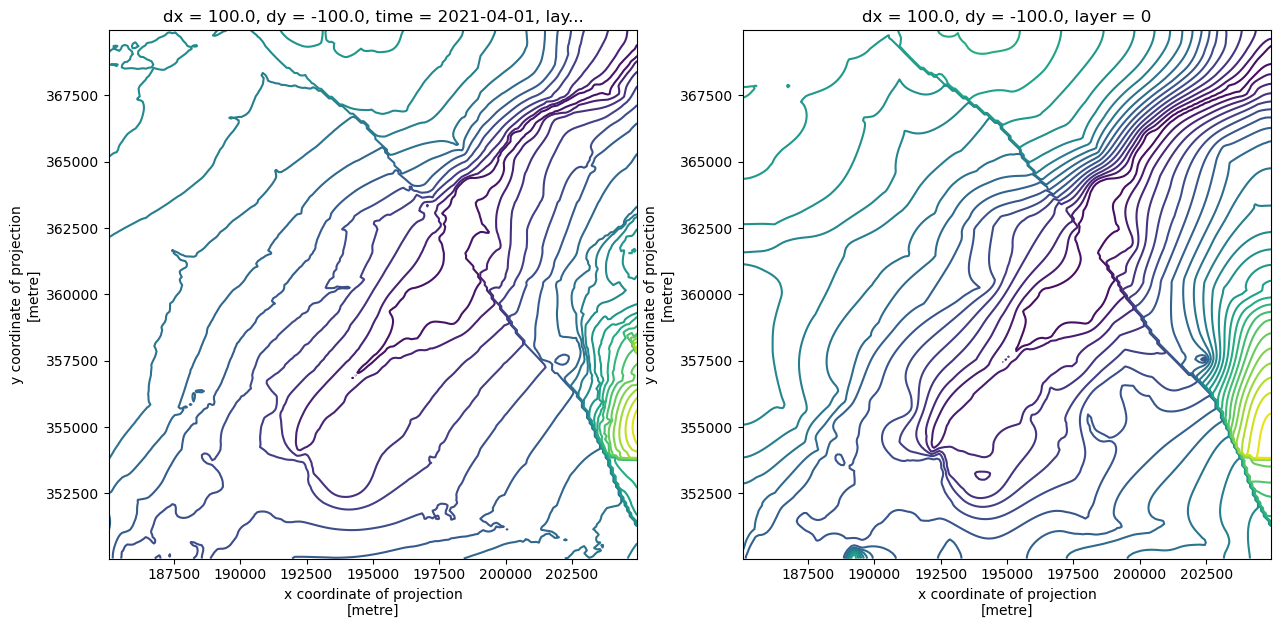

In [ ]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(15, 7))
modelhead.plot.contour(ax=ax0, levels=30)
inversehead.plot.contour(ax=ax1, levels=30)
ax0.set_aspect(1.0)
ax1.set_aspect(1.0)

<xarray.DataArray 'head' ()> Size: 8B
array(0.27709811)
Coordinates:
    dx       float64 8B 100.0
    dy       float64 8B -100.0
    time     datetime64[ns] 8B 2021-04-01
['_recharge', 'recharge']
0.0008001782407763493


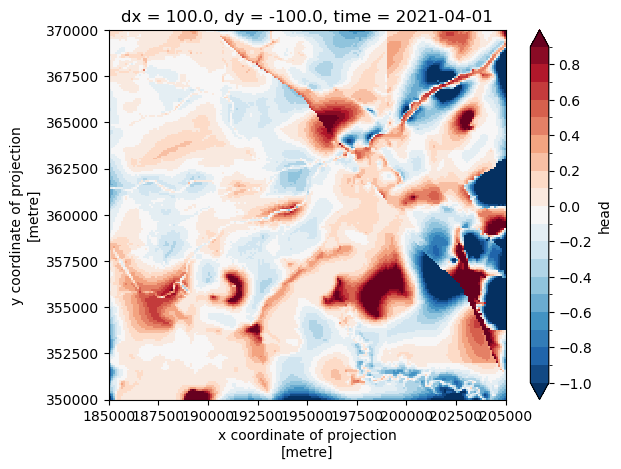

In [ ]:
error.plot.imshow(levels=np.arange(-1.0, 1.0, 0.1))
print(abs(error).mean())
print([a for a in dir(inverse) if 'recharge' in a.lower() or 'rate' in a.lower()])
print(float(inverse.recharge.mean()))

In [ ]:
# Save run parameters + fitted recharge stats
scenario_label = SCENARIO if SCENARIO else "original"

with open("recharge_per_scenario.txt", "a") as f:
    f.write(
        f"scenario={scenario_label}, "
        f"SEED={SEED}, "
        f"REG_WEIGHT={REG_WEIGHT}, "
        f"TRANSMISSIVITY={TRANSMISSIVITY}, "
        f"recharge_mean={float(inverse.recharge.mean()):.6e}, "
        f"recharge_median={float(np.median(np.asarray(inverse.recharge))):.6e}\n"
    )

print("saved:", scenario_label)

saved: original


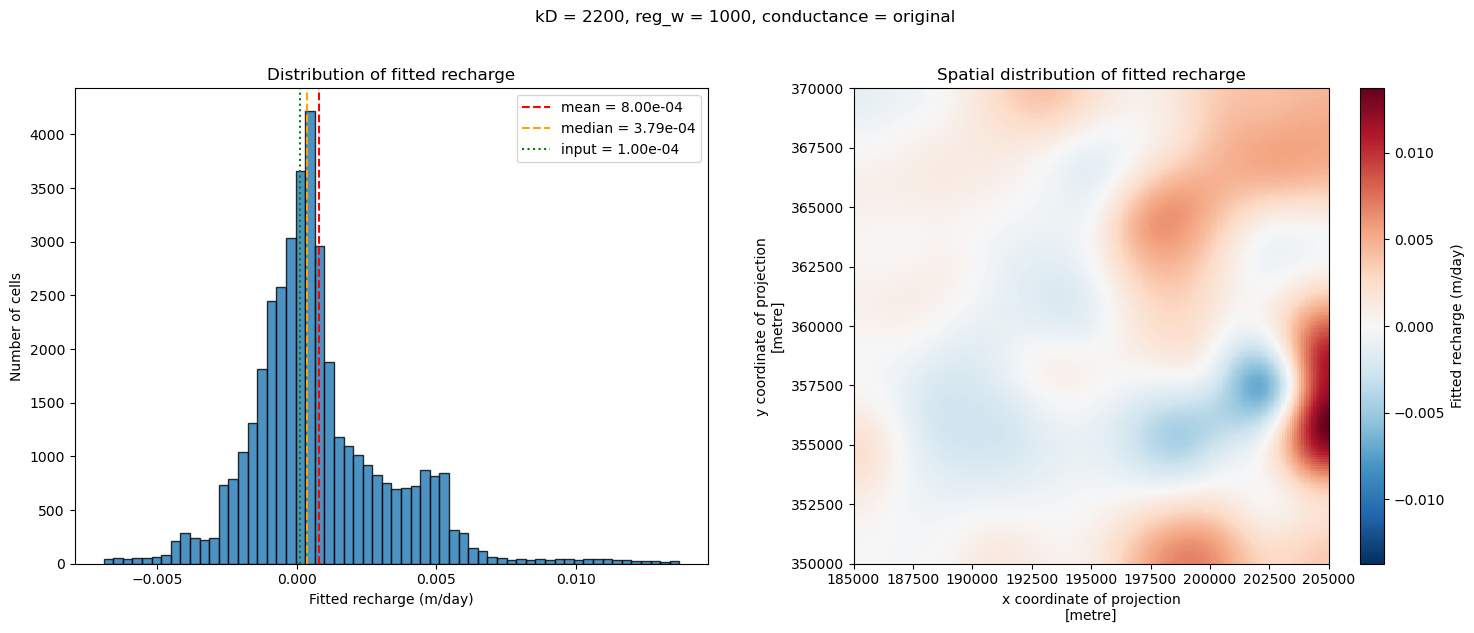

In [ ]:
# Fitted recharge: histogram + spatial map  (run after a SINGLE inverse solve)
from pathlib import Path

OUTDIR = Path(__file__).resolve().parent.parent / "Findings"
OUTDIR.mkdir(parents=True, exist_ok=True)

scenario_label = SCENARIO.lstrip("-") if SCENARIO else "original"

rech_da = inverse.recharge
rech = np.asarray(rech_da).ravel()
rech = rech[np.isfinite(rech)]

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(15, 6))

ax0.hist(rech, bins=60, edgecolor="black", alpha=0.8)
ax0.axvline(np.mean(rech),   color="red",    linestyle="--", label=f"mean = {np.mean(rech):.2e}")
ax0.axvline(np.median(rech), color="orange", linestyle="--", label=f"median = {np.median(rech):.2e}")
ax0.axvline(RECHARGE,        color="green",  linestyle=":",  label=f"input = {RECHARGE:.2e}")
ax0.set_xlabel("Fitted recharge (m/day)")
ax0.set_ylabel("Number of cells")
ax0.set_title("Distribution of fitted recharge")
ax0.legend()

vmax = np.nanmax(np.abs(rech))
rech_da.plot.imshow(
    ax=ax1, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    cbar_kwargs={"label": "Fitted recharge (m/day)"}, add_labels=True,
)
ax1.set_aspect("equal")
ax1.set_title("Spatial distribution of fitted recharge")

plt.suptitle(f"kD = {TRANSMISSIVITY:.0f}, reg_w = {REG_WEIGHT}, conductance = {scenario_label}", y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / f"recharge_kD{int(TRANSMISSIVITY)}_reg{REG_WEIGHT}_{scenario_label}.png",
            dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xugrid as xu
from shapely.geometry import Point
import gc

import respighi as rsp

In [ ]:
# Set window for area of interest

XMIN = 185_000.0
XMAX = 205_000.0
YMIN = 350_000.0
YMAX = 370_000.0
# XMIN = 170_000.0
# XMAX = XMIN + 15_000.0
# YMIN = 360_000.0
# YMAX = YMIN + 15_000.0

#Define parameters
N_PIEZOMETERS = 200
TRANSMISSIVITY = 2200.00
RECHARGE = 0.0001
REG_WEIGHT = 1000
SEED = 12345

In [ ]:
def slice_dataset(ds):
    return ds.sel(x=slice(XMIN, XMAX), y=slice(YMAX, YMIN))

SCENARIO = ""   # "" for original, "-cond0.5", "-cond2", "-cond3"

BASE = "../../case/ibrahym/ibrahym-"

head = xr.open_dataset(f"{BASE}head-l1-100m.nc")["head"]
modelhead = slice_dataset(head.isel(time=-1))
drain_ds        = slice_dataset(xr.open_dataset(f"{BASE}drains-100m{SCENARIO}.nc"))
river_ds        = slice_dataset(xr.open_dataset(f"{BASE}rivers-100m{SCENARIO}.nc"))
large_river_ds  = slice_dataset(xr.open_dataset(f"{BASE}largerivers-100m{SCENARIO}.nc"))
tiledrain_ds    = slice_dataset(xr.open_dataset(f"{BASE}tiledrainage-100m{SCENARIO}.nc"))
overlandflow_ds = slice_dataset(xr.open_dataset(f"{BASE}overlandflow-100m.nc"))  # always original
subsoil         = slice_dataset(xr.open_dataset(f"{BASE}subsoil-100m.nc"))       # always original
hfb_gdf         = gpd.read_file(f"{BASE.replace('ibrahym-', '')}hfb-12.gpkg")

# Select the winter data
river_ds = river_ds.isel(time=0)

# Create a transmissivity
transmissivity = xr.full_like(subsoil["kh"].isel(layer=0, drop=True), TRANSMISSIVITY)

In [ ]:
# Initialize the relevant boundary condition classes, initialize the
# groundwater model, formulate, then solve.

river = rsp.River.from_dataset(river_ds)
large_river = rsp.River.from_dataset(large_river_ds)
drain = rsp.Drainage.from_dataset(drain_ds)
tiledrain = rsp.Drainage.from_dataset(tiledrain_ds)
overlandflow = rsp.Drainage.from_dataset(overlandflow_ds, constant_conductance=500.0)
recharge = rsp.Recharge(
    rate=xr.full_like(transmissivity, RECHARGE).to_numpy(),
)

hfb = rsp.HorizontalFlowBarrier.from_geodataframe(
    layer=0,
    barriers=hfb_gdf,
    template=transmissivity,
    max_snap_distance=10.0,
) #can be skipped

17.14585996629499
12.830262434492436
2.526016825880724
2.2175777664860057
1.5829168230644157
1.0095105186691669
0.033053666535383996
0.00013389663125096263
7.640827138999384e-06
3.719506764809921e-07


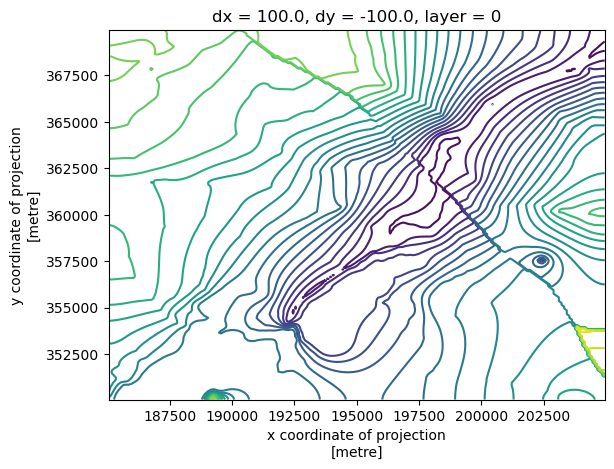

In [ ]:
gwf = rsp.GroundwaterModel(
    area=100.0 * 100.0,
    initial=modelhead,
    recharge=recharge,
    head_boundaries=[river, large_river, drain, tiledrain, overlandflow],
    transmissivity=transmissivity,
    horizontal_flow_barriers=[hfb],
    xclose=1e-6,
    maxiter=50,
)
gwf.formulate()
gwf.nonlinear_solve()
gwf.head.isel(layer=0).plot.contour(levels=30)

In [ ]:
# Make synthetic piezometers


def make_piezometers(n_piezometers, xmin, xmax, ymin, ymax):
    rng = np.random.default_rng(seed=SEED)
    x = xmin + (xmax - xmin) * rng.random(n_piezometers)
    y = ymin + (ymax - ymin) * rng.random(n_piezometers)
    return x, y

#Loading fixed piezometer locations (Cannot be used in conjunction with make_piezometers function, 
# as it will overwrite the generated piezometer locations with the ones from the file)
# piezometers_gdf = gpd.read_file(f"piezometers_seed{SEED}.gpkg")
# x = piezometers_gdf.geometry.x.to_numpy()
# y = piezometers_gdf.geometry.y.to_numpy()


x, y = make_piezometers(
    n_piezometers=200,
    xmin=XMIN,
    xmax=XMAX,
    ymin=YMIN,
    ymax=YMAX,
)

#Store fixed piezometer locations in a GeoPackage file for future reference
geometry = [Point(xi, yi) for xi, yi in zip(x, y)]
piezometers_gdf = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:28992")
piezometers_gdf.to_file(f"piezometers_seed{SEED}.gpkg", driver="GPKG")

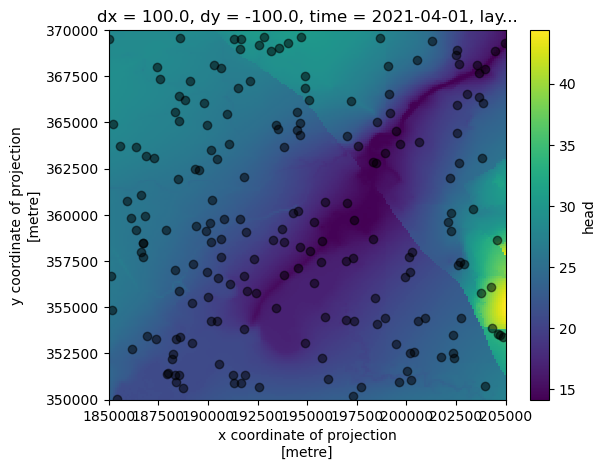

In [ ]:
# Check where they are located
fig, ax = plt.subplots()
modelhead.plot(ax=ax)
ax.scatter(x, y, color="k", alpha=0.5)

In [ ]:
# Make a respighi Target

grid = xu.Ugrid2d.from_structured(modelhead)
headvalues = modelhead.sel(
    x=xr.DataArray(x), y=xr.DataArray(y), method="nearest"
).to_numpy()
target = rsp.CellSampling(x, y, headvalues, grid)

In [ ]:
# Inverse Problem
# ---------------
#
# With the groundwater model and the target, we can pose an inverse problem to solve.

inverse = rsp.InverseProblem(
    groundwatermodel=gwf,
    target=target,
    regularization_weight=REG_WEIGHT,
    maxiter=100,
    relax=0.0,
)

In [ ]:
inverse.formulate()

In [ ]:
# Solve.

inverse.nonlinear_solve()

133.54730275547465
112.79332443013739
33.20419802857894
4.993653298392648
2.1894029388934193
0.19626104857185567
0.024018981940809425
0.023188329841698163
0.021689187539891464
0.02168009625719236
0.02166759187075229
0.021665540629047797
0.021662792574108636
0.021662335174696068
0.02166173569384
0.021661634007244857
0.021661498253468636
0.021661474868242436
0.0216614426890942
0.021661438271824096
0.021661434262565393
0.021661430634679846
0.02166142118473502
0.0216614229341765
0.021661435911813243
0.02166143593235148
0.02166143519848518
0.021661435300657672
0.021661436177382143
0.021661434592481044
0.021661423527753243
0.021661423597628016
0.0216614219965372
0.021661421913776735
0.02166142103684976
0.021661421403791792
0.021661421950380344
0.02166142086066003
0.021661421214030696
0.021661422455792945
0.021661422425509613
0.021661421876533637
0.021661421031055283
0.021661422330083724
0.021661435086205216
0.021661433232591065
0.02166142031479623
0.02166142282601413
0.021661436967502112
0.0

C:\Users\sebas\Documents\1Thesis\respighi\respighi\inverse.py:306: UserWarning: Nonlinear solver did not converge after 100 iterations. Final update: 2.17e-02
  warnings.warn(


(False, 100)

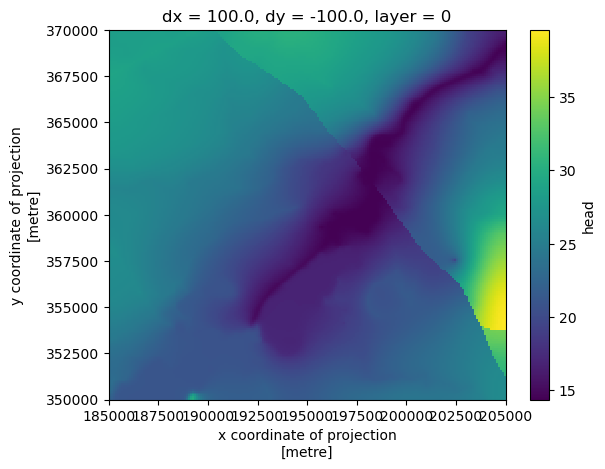

In [ ]:
inversehead = inverse.head.isel(layer=0)
inversehead.plot.imshow()

In [ ]:
error = inversehead - modelhead
print(abs(error).mean())

<xarray.DataArray 'head' ()> Size: 8B
array(0.27709811)
Coordinates:
    dx       float64 8B 100.0
    dy       float64 8B -100.0
    time     datetime64[ns] 8B 2021-04-01


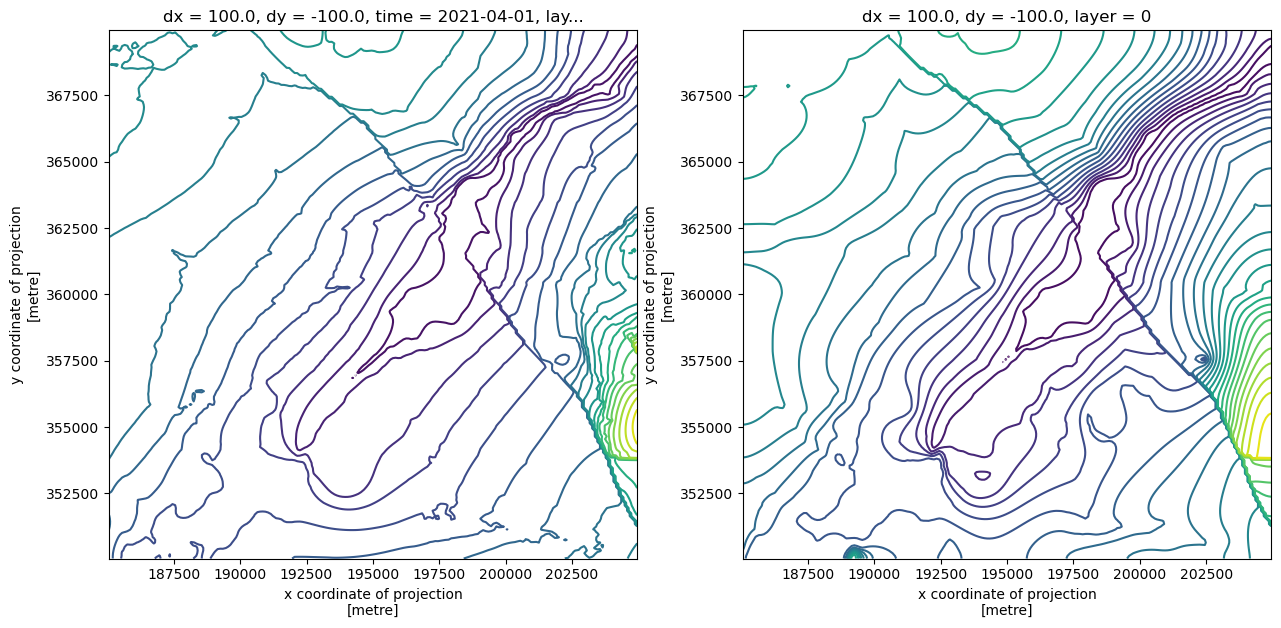

In [ ]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(15, 7))
modelhead.plot.contour(ax=ax0, levels=30)
inversehead.plot.contour(ax=ax1, levels=30)
ax0.set_aspect(1.0)
ax1.set_aspect(1.0)

<xarray.DataArray 'head' ()> Size: 8B
array(0.27709811)
Coordinates:
    dx       float64 8B 100.0
    dy       float64 8B -100.0
    time     datetime64[ns] 8B 2021-04-01
['_recharge', 'recharge']
0.0008001782407763485


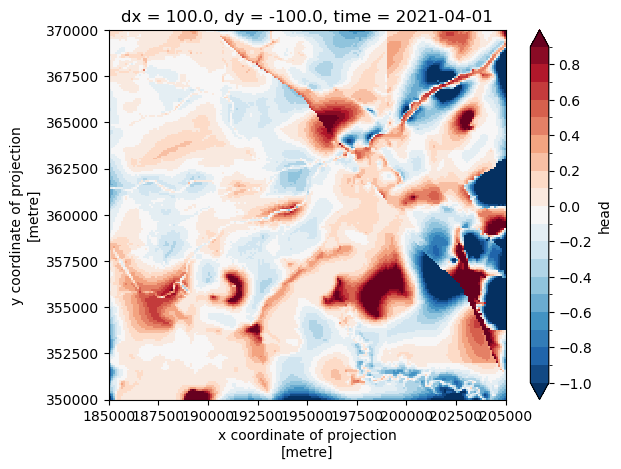

In [ ]:
error.plot.imshow(levels=np.arange(-1.0, 1.0, 0.1))
print(abs(error).mean())
print([a for a in dir(inverse) if 'recharge' in a.lower() or 'rate' in a.lower()])
print(float(inverse.recharge.mean()))

In [ ]:
# Save run parameters + fitted recharge stats
scenario_label = SCENARIO if SCENARIO else "original"

with open("recharge_per_scenario.txt", "a") as f:
    f.write(
        f"scenario={scenario_label}, "
        f"SEED={SEED}, "
        f"REG_WEIGHT={REG_WEIGHT}, "
        f"TRANSMISSIVITY={TRANSMISSIVITY}, "
        f"recharge_mean={float(inverse.recharge.mean()):.6e}, "
        f"recharge_median={float(np.median(np.asarray(inverse.recharge))):.6e}\n"
    )

print("saved:", scenario_label)

saved: original


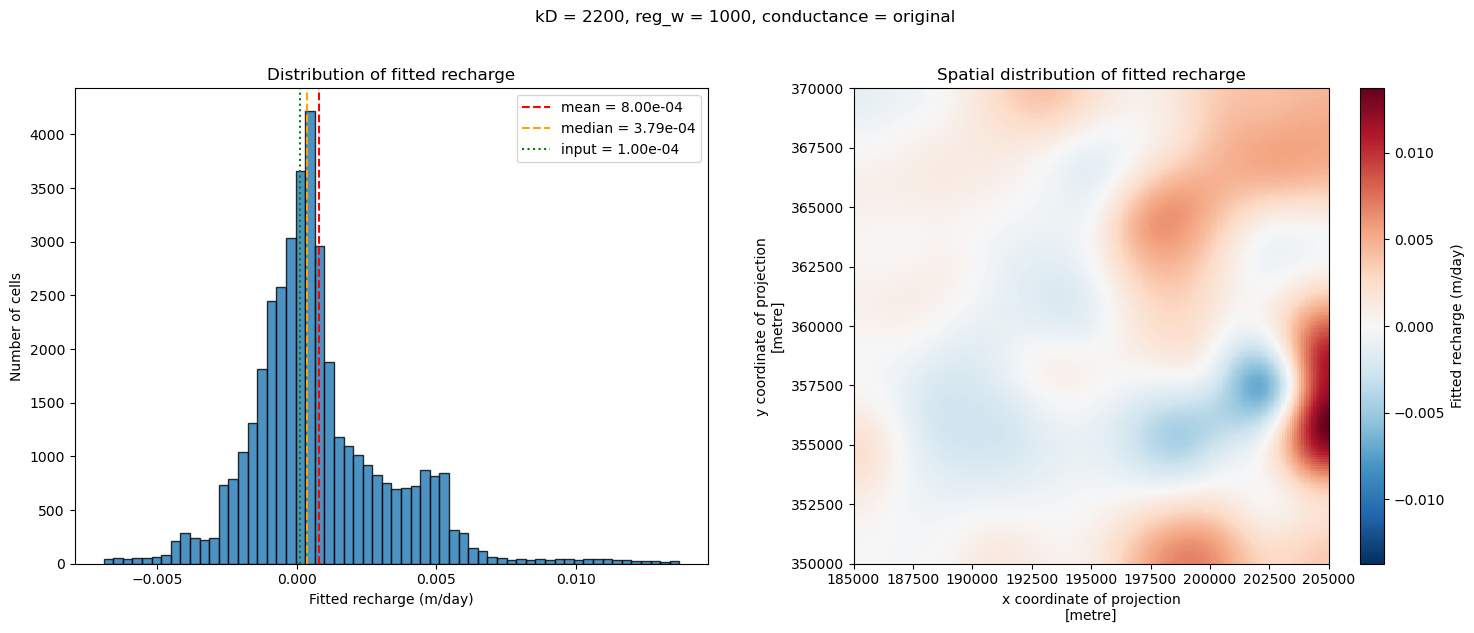

In [ ]:
# Fitted recharge: histogram + spatial map  (run after a SINGLE inverse solve)
from pathlib import Path

OUTDIR = Path(__file__).resolve().parent.parent / "Findings"
OUTDIR.mkdir(parents=True, exist_ok=True)

scenario_label = SCENARIO.lstrip("-") if SCENARIO else "original"

rech_da = inverse.recharge
rech = np.asarray(rech_da).ravel()
rech = rech[np.isfinite(rech)]

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(15, 6))

ax0.hist(rech, bins=60, edgecolor="black", alpha=0.8)
ax0.axvline(np.mean(rech),   color="red",    linestyle="--", label=f"mean = {np.mean(rech):.2e}")
ax0.axvline(np.median(rech), color="orange", linestyle="--", label=f"median = {np.median(rech):.2e}")
ax0.axvline(RECHARGE,        color="green",  linestyle=":",  label=f"input = {RECHARGE:.2e}")
ax0.set_xlabel("Fitted recharge (m/day)")
ax0.set_ylabel("Number of cells")
ax0.set_title("Distribution of fitted recharge")
ax0.legend()

vmax = np.nanmax(np.abs(rech))
rech_da.plot.imshow(
    ax=ax1, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    cbar_kwargs={"label": "Fitted recharge (m/day)"}, add_labels=True,
)
ax1.set_aspect("equal")
ax1.set_title("Spatial distribution of fitted recharge")

plt.suptitle(f"kD = {TRANSMISSIVITY:.0f}, reg_w = {REG_WEIGHT}, conductance = {scenario_label}", y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / f"recharge_kD{int(TRANSMISSIVITY)}_reg{REG_WEIGHT}_{scenario_label}.png",
            dpi=200, bbox_inches="tight")
plt.show()

31.49337446880849
29.568595542028977
5.030273256480253
3.2196439138888415
2.046721820910566
2.092917403252059
0.6929701488931208
0.04282103987906538
0.002737090244483653
0.0025620807898150133
0.002468208181671372
0.0023281810193225283
0.0022480828656128438
0.0021315778253274686
0.0020621102762277133
0.0019645033551896063
0.001903181087115513
0.0018184928701003855
0.0017638331017586495
0.001689751699352371
0.0016395197938265937
0.0015741975130865171
0.001528820581377488
0.0014703969883491652
0.0014297045377524853
0.0013787091315649036
0.001341116146097221
0.0012939878898485802
0.0012597658776805076
0.0012175941851531036
0.0011850507871500326
0.0011460889069248026
0.0011166400847422153
0.001080445553277798
0.0010523856868367432
0.0010195850426057973
0.0009935813169619223
0.0009628452744081528
0.000938504184972544
0.0009102321060190377
0.0008875187170183096
0.000860708837606694
0.0008385127064336473
0.0008131893378795496
0.0007930186399782713
0.0007697250977045655
0.0007499837354316696
0.

C:\Users\sebas\Documents\1Thesis\respighi\respighi\groundwaterflow.py:628: UserWarning: Nonlinear solver did not converge after 50 iterations. Final update: 6.89e-04
  warnings.warn(


247.90826358490793
227.21039089458893
53.472092001297476
5.0234346271498005
1.7663927332125198
0.36155597131996586
0.027387810851312366
0.015129539590393648
0.015151251462118154
0.015202315915662012
0.015206176208955924
0.015215316018284852
0.015215773298695723
0.015216864780622785
0.015216912456100573
0.015217012993279155
0.015217024037958993
0.015217076963711662
0.01521708638211905
0.015217111619115542
0.015217107319998036
0.015217075527790058
0.015217068377094023
0.015217081801594645
0.015217086655042067
0.015217086419347936
0.015217081108449548
0.015217055874057195
0.0152170670075229
0.015217076379645533
0.015217051947590932
0.015216995597494787
0.015217011517801637
0.015217076473572178
0.015217076257499684
0.015217085414214182
0.015217093279396465
0.015217078146331886
0.015217070548537492
0.015217081693876366
0.015217090521289833
0.015217081657795006
0.015217082430314832
0.015217099198792994
0.015217078168078046
0.015217031234566747
0.015217048614939443
0.015217103694173062
0.0152

C:\Users\sebas\Documents\1Thesis\respighi\respighi\inverse.py:306: UserWarning: Nonlinear solver did not converge after 100 iterations. Final update: 1.52e-02
  warnings.warn(


21.85939443048445
19.86747457301918
4.608153727610102
2.2347507519326157
2.428461826349171
1.094133034311131
0.12837738091402429
0.00024455380619059497
0.0001793133387231194
0.00013053258401996004
9.549068591141463e-05
6.86188655265596e-05
4.919033725414579e-05
3.472607301091557e-05
2.5601162423782853e-05
1.9076723727806666e-05
1.3684193394425392e-05
1.0320689757037371e-05
7.725354016940855e-06
6.083904775522342e-06
4.923489775876533e-06
4.044757481835859e-06
3.528503874861144e-06
3.4956208665448685e-06
3.0211191877071997e-06
2.2983935465958893e-06
1.9724005504428987e-06
1.6047291282461629e-06
1.786510974710609e-06
2.3979740220170243e-06
2.761830309339075e-06
2.8344214619835384e-06
1.985630444067965e-06
2.1200901798579252e-06
1.6370980517876887e-06
8.23030422480997e-07
181.36226518412906
160.66918458421955
42.99326595416521
5.057830192357805
2.6700623103268413
0.215042398432157
0.06206844528156452
0.04008445770866231
0.038065453331121546
0.034356631121077896
0.03435664102336489
0.03435

...

17.161718754671682
11.485140887503174
2.6753877614870625
1.841614188773736
1.5542645041351797
0.8112893006172115
0.028037706578174948
0.0006493132403235791
2.8660038609018557e-07
124.43454455339608
103.66764850004994
30.516171024080922
5.062628638171734
1.9602323046593675
0.1932870958335613
0.013014043710086298
0.0016265909413526458
0.000954586653403311
0.0005286181829227132
0.000305299617210153
0.00017271478814606667
9.895195752918085e-05
17.194672900867914
9.2554337585096
2.6349254793115513
1.634520055960465
1.3579689129432957
0.22761680588288868
0.019899919113640863
0.00014112295011159404
8.301469225813207e-06
4.851245876125176e-07
109.3859652372698
88.58684138127765
25.272986249259368
5.155811380058726
1.2676889816868737
0.17737649943301292
0.0029807990525654304
0.00035955332618087255
2.6956131041089293e-05
17.22926475233094
8.603664343153241
2.6549149126354656
1.192915803175321
0.7112329458972226
0.09502256066549464
0.0007645271701548495
3.6284624691518275e-06
2.6250010520811884e-

C:\Users\sebas\Documents\1Thesis\respighi\respighi\inverse.py:306: UserWarning: Nonlinear solver did not converge after 100 iterations. Final update: 2.77e-02
  warnings.warn(


17.266698862636474
8.370307656947524
2.2799531865826843
1.3094850383237038
0.6547946946051049
0.10517381805138726
2.0848144583140993e-05
4.615596633783525e-06
1.5392333168051664e-06
8.070016690453485e-07
90.1242402101133
69.27359065238039
10.231014858837725
4.52622951555551
0.6214991638458116
0.024818196180266483
0.0014583541836259428
6.128978971275956e-05
17.30703797970557
8.20153344519672
1.9345201261546023
1.4117341537594825
0.5721958536932163
0.08570734101789057
0.00039679717736262887
3.2790629614254385e-05
2.7556261663619352e-06
2.3633267431932836e-07
83.62006822137086
62.755822917371106
6.856687694256054
4.133347007074935
0.5611956697015295
0.009208001367616347
0.0012112969899717996
0.0003107844723153619
9.541909428278927e-05
17.349968204625466
8.095909791687628
1.7800937499081684
1.4835133451970215
0.45492701241682454
0.023817207862943945
2.665006344315657e-05
3.5686892267960957e-06
6.076427858658917e-07
78.39789130866605
57.52486893084104
5.623236455153108
3.3021137392968676
0.

C:\Users\sebas\Documents\1Thesis\respighi\respighi\inverse.py:306: UserWarning: Nonlinear solver did not converge after 100 iterations. Final update: 4.56e-03
  warnings.warn(


17.691955574144757
8.458873861924932
1.9859663304246773
0.3911462559089074
0.021496483113438103
3.143077476508438e-05
1.7983316205061328e-06
1.1384100773170758e-07
59.65314074924291
38.58787097243624
4.730187414407158
0.7303746750612241
0.043269408795852726
0.0009821433337346974
0.00013752080110407405
3.8932505283639784e-05
17.743471961782326
8.52617752449656
2.1050682808584966
0.2591842628802681
0.0732935161840409
0.004764731151965407
3.187459854103736e-05
4.969074751670632e-07
58.06915161725291
36.999273887112736
4.104524844057941
0.6918591385254729
0.03621833332239177
0.006397590452596802
0.0013220548446710723
0.0004997404678022122
0.00016274567908425297
5.132006994301719e-05
17.795124175693037
8.490416959254492
2.181507639595054
0.37994091198327595
0.13594268989365332
0.0109085217144127
2.1769549647387976e-05
1.4514246160501898e-07
56.628266789883206
35.552927710051776
3.6093637022175393
0.6105353043893693
0.02916564490922724
0.0003798956513847429
2.8374133599129436e-05
17.84680401

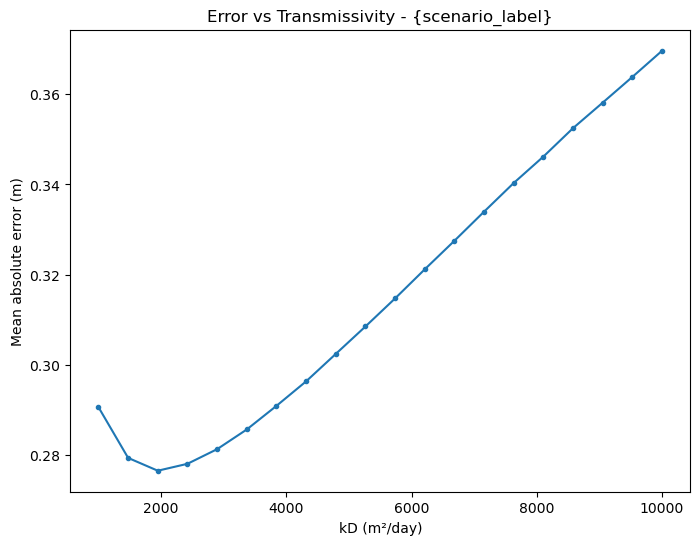

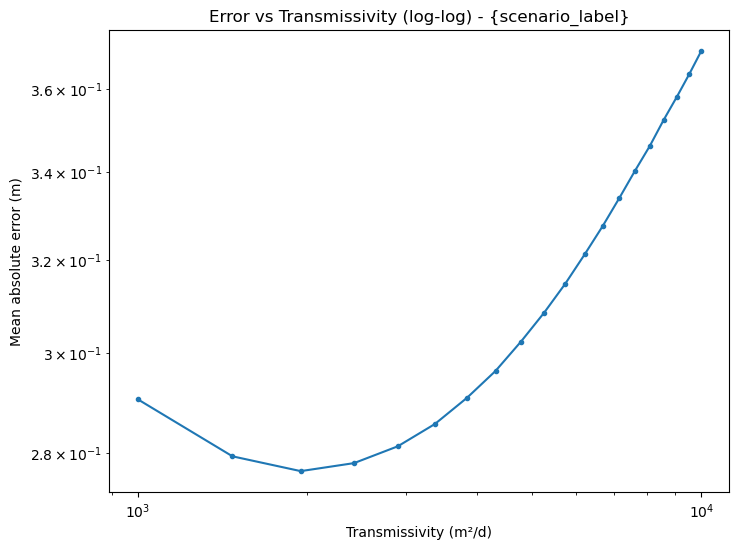

In [ ]:
####============ FOR LOOP FINDING OPTIMUM KD VALUE =============######

kD_values = np.linspace(1000, 10000, 20)
errors = []

for kD in kD_values:
    transmissivity = xr.full_like(subsoil["kh"].isel(layer=0, drop=True), kD)
    recharge = rsp.Recharge(
        rate=xr.full_like(transmissivity, RECHARGE).to_numpy(),
    )
    gwf = rsp.GroundwaterModel(
        area=100.0 * 100.0,
        initial=modelhead,
        recharge=recharge,
        head_boundaries=[river, large_river, drain, tiledrain, overlandflow],
        transmissivity=transmissivity,
        horizontal_flow_barriers=[hfb],
        xclose=1e-6,
        maxiter=50,
    )
    gwf.formulate()
    gwf.nonlinear_solve()
    inverse = rsp.InverseProblem(
        groundwatermodel=gwf,
        target=target,
        regularization_weight=REG_WEIGHT,
        maxiter=100,
        relax=0.0,
    )
    inverse.formulate()
    inverse.nonlinear_solve()
    inversehead = inverse.head.isel(layer=0)
    error = inversehead - modelhead
    errors.append(abs(error).mean().values)

# Linear plot
plt.figure(figsize=(8, 6))
plt.plot(kD_values, errors, marker=".")
plt.xlabel("kD (m²/day)")
plt.ylabel("Mean absolute error (m)")
plt.title("Error vs Transmissivity - {scenario_label}")
plt.show()

# Log plot
plt.figure(figsize=(8, 6))
plt.plot(kD_values, errors, marker=".")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Transmissivity (m²/d)")
plt.ylabel("Mean absolute error (m)")
plt.title("Error vs Transmissivity (log-log) - {scenario_label}")
plt.show()

In [ ]:
# Save ranked kD values (best-fit first) with run parameters
scenario_label = SCENARIO if SCENARIO else "original"

# pair each kD with its error, sort ascending by error
ranked = sorted(zip(kD_values, errors), key=lambda pair: pair[1])

with open("ranked_kD.txt", "a") as f:
    f.write(
        f"# scenario={scenario_label}, SEED={SEED}, REG_WEIGHT={REG_WEIGHT}, "
        f"N_REPEATS={N_REPEATS if 'N_REPEATS' in dir() else 'NA'}, "
        f"kD grid {kD_values.min():.0f}-{kD_values.max():.0f}, {len(kD_values)} pts\n"
    )
    for rank, (kd, err) in enumerate(ranked[:5], start=1):
        f.write(f"rank {rank:2d}: kD={kd:8.1f}, error={err:.6f}\n")
    f.write("\n")   # blank line between runs

print("saved ranking:", scenario_label)

saved ranking: original


In [ ]:
min_error_index = np.argmin(errors)
min_kD = kD_values[min_error_index]
min_error = errors[min_error_index]
print(f"[{scenario_label}] Optimal kD: {min_kD:.2f} m²/day, with mean error: {min_error:.4f} m")

sorted_indices_kD = np.argsort(errors)
top5_indices_kD = sorted_indices_kD[:5]
top5_kD = kD_values[top5_indices_kD]
top5_errors_kD = np.array(errors)[top5_indices_kD]

for i in range(5):
    print(f"[{scenario_label}] Rank {i+1}: kD = {top5_kD[i]:.2f}, error = {top5_errors_kD[i]:.4f} m")

[original] Optimal kD: 1947.37 m²/day, with mean error: 0.2765 m
[original] Rank 1: kD = 1947.37, error = 0.2765 m
[original] Rank 2: kD = 2421.05, error = 0.2781 m
[original] Rank 3: kD = 1473.68, error = 0.2794 m
[original] Rank 4: kD = 2894.74, error = 0.2813 m
[original] Rank 5: kD = 3368.42, error = 0.2857 m
